# Explicación

## Simulated Annealing para el Set‑Covering Problem (SCP)
### Explicación paso a paso + pseudocódigo

> **Qué hace el programa:** arma una solución que funcione, la va
> retocando muchas veces cambiando unos pocos subconjuntos cada vez, de vez en
> cuando acepta a propósito un retoque que empeora las cosas para no quedarse
> encajonado, y se vuelve más exigente a medida que avanza, hasta quedarse con
> la solución **más barata** que logró encontrar.
>
> Está basado en la heurística de búsqueda local (LSH) de **Jacobs & Brusco
> (1995)** y trabaja sobre las mismas estructuras binarias de los Talleres 1‑3.

---

## Parte 1

Imagina que tienes **n tareas** que dejar cubiertas (los *elementos*). Para
lograrlo puedes contratar **paquetes de trabajo** (los *subconjuntos*): cada
paquete cubre solo algunas tareas y tiene un **precio** (su *costo*). La meta es
elegir un grupo de paquetes que, entre todos, cubra **todas** las tareas
gastando **lo menos posible**.

Probar todas las combinaciones es inviable (con *m* paquetes hay 2^m
posibilidades), así que usamos un método astuto que no garantiza la respuesta
perfecta, pero encuentra una muy buena rápido: el **Recocido Simulado**.

#### **Cómo se anota una solución: el vector binario.**
Una solución es simplemente una **lista de ceros y unos de largo m** (un
*subconjunto seleccionado* por posición). Si la posición *i* vale **1**, el
paquete *i* está contratado; si vale **0**, quedó fuera.

> Ejemplo: `0 0 1 1 0 0 0 0 0 1` significa "contraté los paquetes 3, 4 y 10".

A partir de esa lista se calculan dos cosas: el **costo total** (sumar los
precios de los paquetes en 1) y si es **factible** (que ninguna tarea quede sin
cubrir).

### Paso 1 — Preparación: el "orden natural"
Antes de empezar, ordenamos los paquetes del más conveniente al menos: primero
los **más baratos** y, entre los que cuestan igual, los que **cubren más
tareas**. Esto se hace una sola vez y sirve para elegir bien después.

### Paso 2 — CONSTRUCT: armar una primera solución que funcione
Vamos tarea por tarea: tomamos una tarea que todavía nadie cubre y contratamos
al paquete **barato y conveniente** que la cubra (el primero del orden natural).
Repetimos hasta cubrir las *n* tareas. Al final revisamos si algún paquete quedó
**de más** (todas sus tareas ya las cubre otro) y lo soltamos para ahorrar. Ya
tenemos un grupo que sirve… aunque seguramente todavía se puede abaratar.

### Paso 3 — SEARCH: proponer una solución "vecina"
Aquí **no** cambiamos todo de golpe. Despedimos a **unos pocos paquetes al
azar** (cuántos lo decide **ρ₁**). Como ahora quedan tareas sin cubrir, volvemos
a contratar para taparlas, pero por conveniencia: entra primero quien cubra
muchas tareas pendientes por poco dinero (el parámetro **ρ₂** marca hasta qué
tan caro podemos llegar a considerar). Soltamos a los que sobren otra vez. El
resultado es un grupo **vecino**: parecido al anterior, pero un poco cambiado.

### Paso 4 — Decidir si nos quedamos con el vecino (criterio de Metropolis)
Comparamos el grupo nuevo con el que teníamos:

- Si el nuevo cuesta **igual o menos** → nos quedamos con él, sin dudarlo.
- Si cuesta **más** → a veces igual lo aceptamos, **a propósito**. Suena raro,
  pero a veces hay que empeorar un poquito para luego poder mejorar mucho, igual
  que tienes que salir de un hoyo pequeño para encontrar uno más profundo.

### Paso 5 — La temperatura y el enfriamiento
¿Qué tan dispuestos estamos a aceptar un grupo peor? Eso lo controla un número
llamado **temperatura** (la idea viene de la metalurgia: un metal se calienta y
luego se enfría despacio para quedar más fuerte).

- Al **principio** la temperatura está **alta**: somos flexibles y aceptamos
  muchos cambios malos → **exploramos** sin miedo.
- Poco a poco **bajamos** la temperatura (la multiplicamos por **CF** cada
  **TL** intentos): nos volvemos exigentes y casi solo aceptamos mejoras →
  **nos asentamos**.

Gracias a esto no nos quedamos atrapados en la primera solución decente.

### Paso 6 — Repetir y guardar al mejor
Repetimos los pasos 3, 4 y 5 una y otra vez, con un **límite** para no
eternizarnos (aquí: hasta 1000 intentos o 60 segundos, lo que pase primero).
Durante todo el camino vamos **anotando aparte el mejor grupo** que hayamos
visto, por si más adelante aceptamos uno peor y no queremos perderlo.

### Paso 7 — Hacerlo 10 veces y resumir
Como en el proceso hay azar (a quién despedimos, cómo se rompen los empates), el
resultado puede cambiar de una vez a otra. Por eso corremos todo el proceso
**10 veces** y reportamos: cuánto dio cada corrida, cuál fue el mejor de todos,
el **promedio** y cuánto varían entre sí (la **desviación estándar**). Si las 10
dan resultados parecidos, sabemos que el método es confiable y no fue suerte.

> **Comprobación:** en la instancia de referencia (SCP_simple1, n = 20, m = 10)
> la mejor solución cuesta **6** (paquetes 3, 4 y 10), y las 10 corridas dan
> exactamente eso, lo que confirma que funciona de forma estable.

## Pseudocódigo

### Notación
- `n` = número de **elementos** (tareas a cubrir).
- `m` = número de **subconjuntos** (paquetes disponibles).
- `x` = vector binario de largo `m`; `x[i] = 1` ⇔ el subconjunto `i` está elegido.
- `w[j]` = cuántos subconjuntos **elegidos** cubren el elemento `j`
  (la solución es factible si `w[j] ≥ 1` para todo `j`).
- `costo(i)` = precio del subconjunto `i`;  `cubre(i)` = elementos que cubre `i`.
- **Orden natural:** subconjuntos ordenados por costo ascendente y, ante empate,
  por cobertura (cantidad de elementos) descendente.

### Operaciones básicas y funciones reutilizadas (Talleres 1‑3)
```
funcion_objetivo(x)        = suma de costo(i) para todo i con x[i] = 1
es_factible(x)             = verdadero si w[j] ≥ 1 para todo elemento j

AGREGAR(i, x, w):          x[i] ← 1 ;  w[e] ← w[e] + 1  para cada e en cubre(i)
QUITAR(i, x, w):           x[i] ← 0 ;  w[e] ← w[e] − 1  para cada e en cubre(i)
```

### Eliminación de subconjuntos redundantes
```
funcion ELIMINAR_REDUNDANTES(x, w):
    para cada subconjunto i con x[i] = 1, recorridos de MAYOR a menor costo:
        si todos los elementos de cubre(i) tienen w ≥ 2:   # quitarlo no descubre nada
            QUITAR(i, x, w)
```

### Módulo CONSTRUCT — solución inicial factible (golosa)
```
funcion CONSTRUCT(instancia):
    x ← vector de m ceros
    w[j] ← 0  para cada elemento j = 1..n
    sin_cubrir ← { 1, 2, ..., n }

    mientras sin_cubrir no esté vacío:
        j ← un elemento al azar de sin_cubrir
        i ← el PRIMER subconjunto que cubre j según el orden natural
        AGREGAR(i, x, w)
        sin_cubrir ← sin_cubrir − cubre(i)

    ELIMINAR_REDUNDANTES(x, w)
    retornar (x, w)
```

### Módulo SEARCH — generar un vecino (vecindario ρ₁, ρ₂)
```
funcion SEARCH(x, w, instancia, ρ1, ρ2):
    S ← { subconjuntos i con x[i] = 1 }
    N ← |S|
    Q ← costo máximo entre los subconjuntos de S
    D ← techo(ρ1 · N)   acotado a   1 ≤ D ≤ N      # cuántos quitar (perturbación)
    E ← máx( techo(ρ2 · Q), Q )                     # cota de costo para reingresar

    # 1) Perturbar: quitar D subconjuntos al azar
    elegir D subconjuntos distintos al azar de S
    para cada uno de ellos i:  QUITAR(i, x, w)

    # 2) Reparar la factibilidad de forma golosa
    sin_cubrir ← { elementos j con w[j] = 0 }
    mientras sin_cubrir no esté vacío:
        candidatos ← { i : x[i] = 0  y  costo(i) ≤ E  y  i cubre algún elemento sin_cubrir }
        para cada i en candidatos:
            α(i) ← cantidad de elementos sin_cubrir que cubre i
            β(i) ← costo(i) / α(i)                  # razón costo / cobertura
        i* ← el candidato de menor β   (si hay empate, elegir al azar)
        AGREGAR(i*, x, w)
        sin_cubrir ← sin_cubrir − cubre(i*)

    # 3) Limpiar
    ELIMINAR_REDUNDANTES(x, w)
    retornar (x, w)
```

### Ciclo principal — Recocido Simulado
```
funcion RECOCIDO_SIMULADO(instancia, ρ1, ρ2, T0, CF, TL, max_evals, max_tiempo):
    (x, w) ← CONSTRUCT(instancia)
    z      ← funcion_objetivo(x)
    (x*, z*) ← (x, z)                 # mejor solución encontrada (S*)

    T ← T0
    evals ← 0
    t0 ← tiempo_actual()

    mientras evals < max_evals  y  (tiempo_actual() − t0) < max_tiempo:
        repetir TL veces:
            si evals ≥ max_evals o se agotó el tiempo: salir del bucle interno

            (x', w') ← SEARCH(x, w, instancia, ρ1, ρ2)
            z'       ← funcion_objetivo(x')
            evals    ← evals + 1
            δ        ← z' − z

            si δ ≤ 0:                                  # vecino igual o mejor
                (x, w, z) ← (x', w', z')
                si z < z*:  (x*, z*) ← (x, z)          # mejora ESTRICTA del óptimo
            si no:                                     # vecino peor
                con probabilidad e^(−δ / T):
                    (x, w, z) ← (x', w', z')           # criterio de Metropolis

        T ← T · CF                                     # enfriamiento

    retornar verificar( crear_solucion(x*) )           # solución óptima hallada
```

### Parámetros usados (referencia: Jacobs & Brusco 1995, Tabla 2)
| Parámetro | Valor | Rol |
|-----------|-------|-----|
| ρ₁ | 0.4 | porcentaje de subconjuntos a retirar (magnitud del vecindario) |
| ρ₂ | 2.0 | profundidad de búsqueda (cota de costo para reingresar) |
| T₀ | 1.3 | temperatura inicial |
| CF | 0.9 | factor de enfriamiento (T ← T·CF cada TL iteraciones) |
| TL | 100 | iteraciones por nivel de temperatura |
| presupuesto | 1000 evals / 60 s | criterio de parada (lo primero que ocurra) |
| corridas | 10 | réplicas independientes con semillas reproducibles |

# Código

In [19]:
import sys
import math
import time
import random
import statistics
import statistics as st # xd
from typing import List, Dict, Set, Tuple
import matplotlib.pyplot as plt

In [20]:
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# PARTE A - ESTRUCTURAS DE DATOS BINARIAS (lo reutilizamos del taller 1 al 3)
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# Estas funciones son las del proyecto de antes (representacion binaria de
# soluciones, lectura de instancias, funcion objetivo, verificacion de
# factibilidad y comparacion). La metaheuristica B opera sobre estas.
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘

def leer_instancia_scp(ruta_archivo: str) -> Dict:
    with open(ruta_archivo, "r", encoding="utf-8") as file:
        data = file.read().split()
    if len(data) < 2:
        raise ValueError("Archivo de instancia vacio o mal formado.")
    num_elementos = int(data[0])        # n
    num_subconjuntos = int(data[1])     # m

    costos: List[float] = []
    idx = 2
    for _ in range(num_subconjuntos):
        costos.append(float(data[idx]))
        idx += 1

    cobertura: Dict[int, List[int]] = {}
    for j in range(1, num_elementos + 1):
        cantidad = int(data[idx])
        idx += 1
        subconjuntos = []
        for _ in range(cantidad):
            subconjuntos.append(int(data[idx]))
            idx += 1
        cobertura[j] = subconjuntos

    return {
        "num_elementos": num_elementos,
        "num_subconjuntos": num_subconjuntos,
        "costos": costos,
        "cobertura": cobertura,
    }


def calcular_funcion_objetivo(vector_binario: List[int], instancia: Dict) -> float:
    costos = instancia["costos"]
    return sum(costos[i] for i, xi in enumerate(vector_binario) if xi == 1)


def crear_solucion(vector_binario: List[int], instancia: Dict) -> Dict:
  # Construye el diccionario que representa una solucion candidata a partir de un vector binario
    m = instancia["num_subconjuntos"]
    costos = instancia["costos"]

    if len(vector_binario) != m:
        raise ValueError(
            f"Dimension incorrecta: el vector tiene {len(vector_binario)} "
            f"elementos, pero la instancia requiere m = {m}."
        )
    if any(xi not in (0, 1) for xi in vector_binario):
        raise ValueError("El vector contiene valores fuera del dominio {0, 1}.")

    subconjuntos_seleccionados = [
        i + 1 for i, xi in enumerate(vector_binario) if xi == 1
    ]
    costo_total = sum(
        costos[i] for i, xi in enumerate(vector_binario) if xi == 1
    )

    return {
        "vector": list(vector_binario),
        "subconjuntos_seleccionados": subconjuntos_seleccionados,
        "num_seleccionados": len(subconjuntos_seleccionados),
        "costo_total": costo_total,
        "es_valida": None,                 # se determina en verificar_solucion
        "elementos_no_cubiertos": [],      # se rellena en verificar_solucion
    }


def verificar_solucion(solucion: Dict, instancia: Dict) -> Dict:
  # todo elemento debe estar cubierto (se usa set para buscar)
    cobertura = instancia["cobertura"]
    n = instancia["num_elementos"]

    seleccionados = set(solucion["subconjuntos_seleccionados"])
    elementos_no_cubiertos = []

    for j in range(1, n + 1):
        subconjuntos_que_cubren_j = set(cobertura[j])
        if subconjuntos_que_cubren_j.isdisjoint(seleccionados):
            elementos_no_cubiertos.append(j)

    solucion["es_valida"] = (len(elementos_no_cubiertos) == 0)
    solucion["elementos_no_cubiertos"] = elementos_no_cubiertos
    return solucion


def comparar_soluciones(solucion_a: Dict, solucion_b: Dict) -> int:
  # para comparar soluciones
    valida_a = solucion_a["es_valida"]
    valida_b = solucion_b["es_valida"]

    if valida_a and not valida_b:
        return -1
    if valida_b and not valida_a:
        return 1

    if valida_a and valida_b:
        ca, cb = solucion_a["costo_total"], solucion_b["costo_total"]
        if ca < cb:
            return -1
        if cb < ca:
            return 1
        return 0

    na = len(solucion_a["elementos_no_cubiertos"])
    nb = len(solucion_b["elementos_no_cubiertos"])
    if na < nb:
        return -1
    if nb < na:
        return 1
    return 0


def visualizar_solucion(solucion: Dict, instancia: Dict) -> None:
    if solucion["es_valida"] is None:
        print("Advertencia: la solucion no ha sido verificada aun.")

    m = instancia["num_subconjuntos"]
    n = instancia["num_elementos"]
    vec = solucion["vector"]
    sel = solucion["subconjuntos_seleccionados"]
    nc = solucion["elementos_no_cubiertos"]

    print()
    print("=" * 50)
    print(" REPORTE DE SOLUCION SCP")
    print("=" * 50)
    print(f" Subconjuntos totales (m) : {m}")
    print(f" Elementos del universo (n): {n}")
    print("-" * 50)

    print(" VECTOR DE DECISION (x_1 ... x_m)")
    BLOQUE = 25
    for inicio in range(0, m, BLOQUE):
        fin = min(inicio + BLOQUE, m)
        fila = "".join(str(xi) for xi in vec[inicio:fin])
        print(f"  [{inicio + 1:>5} - {fin:>5}] {fila}")

    print("-" * 50)
    print(" SUBCONJUNTOS SELECCIONADOS")
    print(f"  Cantidad: {solucion['num_seleccionados']} de {m}")
    GRUPO = 15
    for k in range(0, len(sel), GRUPO):
        grupo_str = " ".join(f"{idx:>4}" for idx in sel[k:k + GRUPO])
        print(f"  {grupo_str}")

    print("-" * 50)
    print(f" Costo Total : {solucion['costo_total']:.2f}")
    print("-" * 50)
    if solucion["es_valida"]:
        print(" Estado : [OK] SOLUCION VALIDA")
        print(" Todos los elementos estan cubiertos.")
    else:
        print(" Estado : [X] SOLUCION INVALIDA")
        print(f" Elementos no cubiertos : {len(nc)} de {n}")
        muestra = nc[:20]
        sufijo = " ..." if len(nc) > 20 else ""
        print(f" Indices : {muestra}{sufijo}")
    print("=" * 50)
    print()

    
    Precalcula estructuras auxiliares a partir de la instancia:

      - elementos_de[i]    : tupla de elementos (1..n) que cubre el subconjunto
                             i (1..m). Es la "transpuesta" de 'cobertura'.
      - orden_natural      : lista de subconjuntos (1..m) en el ORDEN NATURAL
                             del paper: costo ascendente y, ante empate, mayor
                             cobertura (numero de elementos) primero.
      - cobertura_orden[j] : subconjuntos que cubren el elemento j, ordenados
                             segun el orden natural (asi, "el mejor subconjunto
                             que cubre j" es cobertura_orden[j][0]).
  

In [21]:
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# PARTE B - METAHEURISTICA: SIMULATED ANNEALING (Jacobs & Brusco, 1995)
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# La metaheuristica trabaja con el vector binario de la Parte A. Internamente
# mantiene, ademas del vector, un arreglo de cobertura w para insertar/quitar
# subconjuntos de forma eficiente:
#       w[j] = numero de subconjuntos SELECCIONADOS que cubren el elemento j.
# La solucion es factible si y solo si w[j] >= 1 para todo elemento j.
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘

def preparar(instancia: Dict) -> Tuple[Dict[int, Tuple[int, ...]],
                                        List[int],
                                        Dict[int, Tuple[int, ...]]]:
    n = instancia["num_elementos"]
    m = instancia["num_subconjuntos"]
    costos = instancia["costos"]
    cobertura = instancia["cobertura"]

    # elementos que cubre cada subconjunto
    elementos_tmp: List[Set[int]] = [set() for _ in range(m + 1)]  # 1..m
    for j in range(1, n + 1):
        for i in cobertura[j]:
            elementos_tmp[i].add(j)
    elementos_de = {i: tuple(sorted(elementos_tmp[i])) for i in range(1, m + 1)}

    # Orden natural - costo asc
    orden_natural = sorted(
        range(1, m + 1),
        key=lambda i: (costos[i - 1], -len(elementos_de[i]))
    )
    rango = {i: r for r, i in enumerate(orden_natural)}

    # Para cada elemento, sus subconjuntos cubridores en orden natural
    cobertura_orden = {
        j: tuple(sorted(cobertura[j], key=lambda i: rango[i]))
        for j in range(1, n + 1)
    }
    return elementos_de, orden_natural, cobertura_orden


def agregar(i: int, vector: List[int], w: List[int],
             elementos_de: Dict[int, Tuple[int, ...]]) -> None:
    # Activa el subconjunto i en el vector y actualiza la cobertura w
    vector[i - 1] = 1
    for e in elementos_de[i]:
        w[e] += 1


def quitar(i: int, vector: List[int], w: List[int],
            elementos_de: Dict[int, Tuple[int, ...]]) -> None:
    # Desactiva el subconjunto i en el vector y actualiza la cobertura w.
    vector[i - 1] = 0
    for e in elementos_de[i]:
        w[e] -= 1


def eliminar_redundantes(vector: List[int], w: List[int], instancia: Dict,
                          elementos_de: Dict[int, Tuple[int, ...]]) -> None:
    # Un subconjunto i es redundante si, al quitarlo, todos los elementos que cubria siguen teniendo otra cobertura
    costos = instancia["costos"]
    m = instancia["num_subconjuntos"]
    seleccionados = [i for i in range(1, m + 1) if vector[i - 1] == 1]
    seleccionados.sort(key=lambda i: costos[i - 1], reverse=True)  # caros primero
    for i in seleccionados:
        if all(w[e] >= 2 for e in elementos_de[i]):
            quitar(i, vector, w, elementos_de)


def construir(instancia: Dict,
              elementos_de: Dict[int, Tuple[int, ...]],
              cobertura_orden: Dict[int, Tuple[int, ...]],
              rng: random.Random) -> Tuple[List[int], List[int]]:
    # genera una solucion inicial FACTIBLE - heuristica golosa
    # elementos sin cubrir -> uno al azar -> agrega 1mer subconjunto. Al final se descartan los redundantes
    n = instancia["num_elementos"]
    m = instancia["num_subconjuntos"]

    vector = [0] * m
    w = [0] * (n + 1)                       #  indices 1..n
    sin_cubrir: Set[int] = set(range(1, n + 1))

    while sin_cubrir:
        j = rng.choice(tuple(sin_cubrir))            # elemento sin cubrir al azar
        i = cobertura_orden[j][0]                    # mejor subconjunto que lo cubre
        agregar(i, vector, w, elementos_de)
        sin_cubrir.difference_update(elementos_de[i])

    eliminar_redundantes(vector, w, instancia, elementos_de)
    return vector, w


def generar_vecino(vector_in: List[int], w_in: List[int], instancia: Dict,
                   elementos_de: Dict[int, Tuple[int, ...]],
                   rho1: float, rho2: float,
                   rng: random.Random) -> Tuple[List[int], List[int]]:
    # genera un vecino S' de la solucion actual.
    # rho1: magnitud de la perturbacion. Numero de subconjuntos a retirar
    # rho2: profundidad de busqueda. Cota de costo para los subconjuntos que pueden reingresar

    n = instancia["num_elementos"]
    m = instancia["num_subconjuntos"]
    costos = instancia["costos"]
    cobertura = instancia["cobertura"]

    vector = list(vector_in)
    w = list(w_in)

    #  D y E se calculan sobre la solucion ENTRANTE (N(S) y Q(S)).
    seleccionados = [i for i in range(1, m + 1) if vector[i - 1] == 1]
    N = len(seleccionados)
    Q = max(costos[i - 1] for i in seleccionados)     # S factible => no vacio
    D = math.ceil(rho1 * N)
    D = min(max(D, 1), N)                              # 1 <= D <= N
    E = math.ceil(rho2 * Q)
    # Garantia de reparabilidad: con rho2 >= 1 se cumple E >= Q, de modo que
    # todo subconjunto recien retirado (costo <= Q) sigue siendo candidato.
    E = max(E, Q)

    # retirar D subconjuntos distintos al azar.
    rng.shuffle(seleccionados)
    for i in seleccionados[:D]:
        quitar(i, vector, w, elementos_de)

    # reparar la factibilidad con busqueda golosa acotada por E.
    sin_cubrir = {j for j in range(1, n + 1) if w[j] == 0}
    while sin_cubrir:
        # Candidatos: subconjuntos NO seleccionados, de costo <= E, que cubran
        # algun elemento aun sin cubrir.
        candidatos: Set[int] = set()
        for j in sin_cubrir:
            for i in cobertura[j]:
                if vector[i - 1] == 0 and costos[i - 1] <= E:
                    candidatos.add(i)

        mejor_beta = math.inf
        mejores: List[int] = []
        for i in candidatos:
            # alpha = nro. de elementos AUN sin cubrir que cubre el subconjunto i.
            alpha = 0
            for e in elementos_de[i]:
                if w[e] == 0:
                    alpha += 1
            beta = costos[i - 1] / alpha               # razon costo / cobertura
            if beta < mejor_beta:
                mejor_beta = beta
                mejores = [i]
            elif beta == mejor_beta:
                mejores.append(i)

        i = rng.choice(mejores)                        # desempate aleatorio
        agregar(i, vector, w, elementos_de)
        sin_cubrir.difference_update(elementos_de[i])

    # Paso 6: eliminar subconjuntos redundantes.
    eliminar_redundantes(vector, w, instancia, elementos_de)
    return vector, w


def recocido_simulado(instancia: Dict,
                      rho1: float, rho2: float,
                      T0: float, CF: float, TL: int,
                      max_evaluaciones: int, max_tiempo: float,
                      rng: random.Random,
                      recolectar_traza: bool = False) -> Dict:
    # Criterio de Metropolis: delta <= 0 se acepta siempre; delta > 0 con prob exp(-delta/T).
    # Si recolectar_traza=True, ademas registra telemetria de la busqueda (sin alterar el resultado).
    elementos_de, _orden, cobertura_orden = preparar(instancia)

    vector, w = construir(instancia, elementos_de, cobertura_orden, rng)
    z = calcular_funcion_objetivo(vector, instancia)

    mejor_vector = list(vector)
    mejor_z = z

    T = T0
    evaluaciones = 0
    t_inicio = time.perf_counter()

    # --- telemetria (solo se usa si recolectar_traza=True) ---
    n_mejoras = n_acepta_peor = n_rechaza = 0
    costo_inicial = z
    costos_vistos = {z}
    traza_actual = [z]      # costo de la solucion ACTUAL aceptada, por evaluacion
    traza_mejor = [mejor_z]  # mejor costo hasta el momento, por evaluacion

    while (evaluaciones < max_evaluaciones and
           (time.perf_counter() - t_inicio) < max_tiempo):
        for _ in range(TL):
            if (evaluaciones >= max_evaluaciones or
                    (time.perf_counter() - t_inicio) >= max_tiempo):
                break

            vector_vecino, w_vecino = generar_vecino(
                vector, w, instancia, elementos_de, rho1, rho2, rng
            )
            z_vecino = calcular_funcion_objetivo(vector_vecino, instancia)
            evaluaciones += 1

            delta = z_vecino - z
            if delta <= 0:
                vector, w, z = vector_vecino, w_vecino, z_vecino
                if z < mejor_z:
                    mejor_vector = list(vector)
                    mejor_z = z
                    n_mejoras += 1
            else:
                if rng.random() < math.exp(-delta / T):
                    vector, w, z = vector_vecino, w_vecino, z_vecino
                    n_acepta_peor += 1
                else:
                    n_rechaza += 1

            if recolectar_traza:
                costos_vistos.add(z_vecino)
                traza_actual.append(z)
                traza_mejor.append(mejor_z)

        T *= CF  # enfriamiento

    mejor_solucion = crear_solucion(mejor_vector, instancia)
    mejor_solucion = verificar_solucion(mejor_solucion, instancia)

    if recolectar_traza:
        mejor_solucion["telemetria"] = {
            "costo_inicial": costo_inicial,
            "costo_final": mejor_z,
            "n_mejoras": n_mejoras,
            "n_acepta_peor": n_acepta_peor,
            "n_rechaza": n_rechaza,
            "costos_distintos": len(costos_vistos),
            "min_visto": min(costos_vistos),
            "max_visto": max(costos_vistos),
            "traza_actual": traza_actual,
            "traza_mejor": traza_mejor,
        }
    return mejor_solucion

In [22]:
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# EJECUCION PRINCIPAL: 10 CORRIDAS Y ESTADISTICAS
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘

def main(ruta: str = "/content/03_dificil.txt",
         semilla_base: int = 12345,
         rho1: float = 0.4, rho2: float = 2.0,
         T0: float = 1.3, CF: float = 0.9, TL: int = 100,
         max_evaluaciones: int = 1000, max_tiempo: float = 60.0,
         num_corridas: int = 10) -> None:
    try:
        inst = leer_instancia_scp(ruta)
    except FileNotFoundError:
        print(f"ERROR: no se encontro el archivo de instancia '{ruta}'. ¡Recuerda subirla! :]")
        return

    # ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
    print("=" * 64)
    print(" SIMULATED ANNEALING (SA) para el SCP)")
    print(" Referencia - Jacobs & Brusco (1995), NRL 42:1129-1140")
    print("=" * 64)
    print(f" Instancia            : {ruta}")
    print(f" Elementos (n)        : {inst['num_elementos']}")
    print(f" Subconjuntos (m)     : {inst['num_subconjuntos']}")
    print(f" Parametros           : rho1={rho1}, rho2={rho2}, T0={T0}, "
          f"CF={CF}, TL={TL}")
    print(f" Presupuesto          : {max_evaluaciones} evaluaciones "
          f"(tope {max_tiempo:.0f}s)")
    print(f" Corridas             : {num_corridas}")
    print(f" Semilla base         : {semilla_base}")
    print("=" * 64)

    # Cada corrida usa su propia semilla derivada de la base => experimento
    # reproducible
    valores_objetivo: List[float] = []
    mejor_global: Dict = None

    print("\n Corrida | Funcion objetivo Z(S*)")
    print(" --------+-----------------------")
    for c in range(1, num_corridas + 1):
        rng = random.Random(semilla_base + c)
        sol = recocido_simulado(
            inst, rho1=rho1, rho2=rho2, T0=T0, CF=CF, TL=TL,
            max_evaluaciones=max_evaluaciones, max_tiempo=max_tiempo, rng=rng
        )
        valores_objetivo.append(sol["costo_total"])

        # Mejor solucion global usando el criterio del Taller 3.
        if mejor_global is None or comparar_soluciones(sol, mejor_global) == -1:
            mejor_global = sol

        print(f"   {c:>3}   | {sol['costo_total']:.2f}")

    # ⫘⫘⫘⫘⫘⫘⫘ E S T A D I S T I C A S ⫘⫘⫘⫘⫘⫘⫘
    # statistics.stdev = desviacion estandar MUESTRAL (n-1), apropiada para
    # resumir la variabilidad de un conjunto de replicas estocasticas.
    media = statistics.mean(valores_objetivo)
    desv = statistics.stdev(valores_objetivo) if num_corridas > 1 else 0.0

    print(" --------+-----------------------")
    print(f"\n Media               : {media:.4f}")
    print(f" Desviacion estandar : {desv:.4f}")
    print(f" Minimo (mejor)      : {min(valores_objetivo):.2f}")
    print(f" Maximo (peor)       : {max(valores_objetivo):.2f}")

    print("\n" + "-" * 64)
    print(" MEJOR SOLUCION ENCONTRADA (sobre todas las corridas)")
    print("-" * 64)
    print(f" Funcion objetivo Z(S*) : {mejor_global['costo_total']:.2f}")
    print(f" Nro. de subconjuntos   : {mejor_global['num_seleccionados']}")
    print(f" Subconjuntos (base 1)  : {mejor_global['subconjuntos_seleccionados']}")
    print(f" Factible               : {mejor_global['es_valida']}")
    print("-" * 64)

    # Reporte detallado de la mejor solucion (reutiliza el visualizador base).
    visualizar_solucion(mejor_global, inst)

    # ⫘⫘⫘⫘⫘⫘⫘ Bloque - tablas del informe ⫘⫘⫘⫘⫘⫘⫘
    print(" Valores objetivo (formato columna, copiable al informe):")
    for v in valores_objetivo:
        print(f" {v:.2f}")

In [23]:
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# DIAGNOSTICO
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘

def diagnostico_metaheuristica(ruta: str = "/content/03_dificil.txt",
                               semilla_base: int = 12345,
                               rho1: float = 0.4, rho2: float = 2.0,
                               T0: float = 1.3, CF: float = 0.9, TL: int = 100,
                               max_evaluaciones: int = 1000, max_tiempo: float = 60.0,
                               num_corridas: int = 10, semillas_hist: int = 300,
                               guardar_figura: str = "diagnostico_sa.png") -> None:
    inst = leer_instancia_scp(ruta)

    # Correr las corridas con traza
    tele = []
    for c in range(1, num_corridas + 1):
        rng = random.Random(semilla_base + c)
        sol = recocido_simulado(inst, rho1, rho2, T0, CF, TL,
                                max_evaluaciones, max_tiempo, rng,
                                recolectar_traza=True)
        tele.append(sol["telemetria"])

    # Tabla stdlib
    print("=" * 80)
    print(" DIAGNOSTICO DE LA METAHEURISTICA  (evidencia de que SI trabaja)")
    print("=" * 80)
    print(f"{'Corr':>4} | {'z0 inicial':>10} | {'z* final':>8} | {'Mejoras':>7} | "
          f"{'Acep.peor':>9} | {'Rechaz.':>7} | {'#costos':>7} | {'Rango visto':>12}")
    print("-" * 80)
    for c, t in enumerate(tele, 1):
        rango = f"{int(t['min_visto'])}-{int(t['max_visto'])}"
        print(f"{c:>4} | {t['costo_inicial']:>10.0f} | {t['costo_final']:>8.0f} | "
              f"{t['n_mejoras']:>7} | {t['n_acepta_peor']:>9} | {t['n_rechaza']:>7} | "
              f"{t['costos_distintos']:>7} | {rango:>12}")
    print("-" * 80)
    z0s = [t['costo_inicial'] for t in tele]
    total_peor = sum(t['n_acepta_peor'] for t in tele)
    print(f" Construccion inicial: varia entre {min(z0s):.0f} y {max(z0s):.0f}")
    print(f" Movimientos PEORES aceptados (Metropolis): {total_peor} en total")
    print(f" Todas convergen a z* = {tele[0]['costo_final']:.0f}")
    print("=" * 80)

    # Figura (matplotlib)
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("\n[aviso] matplotlib no disponible: se omite la figura "
              "(la tabla de arriba ya es evidencia suficiente).")
        return

    # Distribucion del costo de la construccion inicial sobre muchas semillas
    elementos_de, _orden, cobertura_orden = preparar(inst)
    inic = []
    for s in range(semillas_hist):
        rng = random.Random(s)
        v, w = construir(inst, elementos_de, cobertura_orden, rng)
        inic.append(calcular_funcion_objetivo(v, inst))

    zstar = tele[0]["costo_final"]
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

    # Convergencia: mejor costo por evaluacion, una linea por corrida
    for t in tele:
        ax[0].plot(t["traza_mejor"], lw=1, alpha=0.8)
    ax[0].axhline(zstar, ls="--", lw=1, color="k")
    ax[0].set_title("(a) Convergencia del mejor costo z*\n(distinto inicio -> mismo optimo)")
    ax[0].set_xlabel("evaluacion"); ax[0].set_ylabel("mejor costo hasta el momento")

    # Trayectoria de la corrida que MAS exploro (mas movimientos peores aceptados)
    k = max(range(len(tele)), key=lambda i: tele[i]["n_acepta_peor"])
    t = tele[k]
    ax[1].plot(t["traza_actual"], lw=1, color="tab:orange", label="costo ACTUAL aceptado")
    ax[1].plot(t["traza_mejor"], lw=1.6, color="tab:blue", label="mejor hasta el momento")
    ax[1].set_title(f"(b) Trayectoria corrida #{k + 1}: sube y baja\n"
                    f"(Metropolis acepta {t['n_acepta_peor']} movimientos peores)")
    ax[1].set_xlabel("evaluacion"); ax[1].set_ylabel("costo"); ax[1].legend(fontsize=8)

    # Histograma de costos iniciales (golosa) vs el optimo del SA
    ax[2].hist(inic, bins=range(int(min(inic)), int(max(inic)) + 2),
               alpha=0.8, color="tab:green", edgecolor="white")
    ax[2].axvline(zstar, ls="--", lw=2, color="k")
    ax[2].set_title(f"(c) Costo de la construccion inicial ({semillas_hist} semillas)\n"
                    f"varia {int(min(inic))}-{int(max(inic))}; el SA llega a {zstar:.0f}")
    ax[2].set_xlabel("costo inicial (golosa)"); ax[2].set_ylabel("frecuencia")

    plt.tight_layout()
    if guardar_figura:
        plt.savefig(guardar_figura, dpi=120, bbox_inches="tight")
        print(f"\nFigura guardada en: {guardar_figura}")
    plt.show()


 SIMULATED ANNEALING (SA) para el SCP)
 Referencia - Jacobs & Brusco (1995), NRL 42:1129-1140
 Instancia            : /content/01_facil.txt
 Elementos (n)        : 50
 Subconjuntos (m)     : 500
 Parametros           : rho1=0.4, rho2=2.0, T0=1.3, CF=0.9, TL=100
 Presupuesto          : 1000 evaluaciones (tope 60s)
 Corridas             : 10
 Semilla base         : 12345

 Corrida | Funcion objetivo Z(S*)
 --------+-----------------------
     1   | 5.00
     2   | 5.00
     3   | 5.00
     4   | 5.00
     5   | 5.00
     6   | 5.00
     7   | 5.00
     8   | 5.00
     9   | 5.00
    10   | 5.00
 --------+-----------------------

 Media               : 5.0000
 Desviacion estandar : 0.0000
 Minimo (mejor)      : 5.00
 Maximo (peor)       : 5.00

----------------------------------------------------------------
 MEJOR SOLUCION ENCONTRADA (sobre todas las corridas)
----------------------------------------------------------------
 Funcion objetivo Z(S*) : 5.00
 Nro. de subconjuntos   : 5
 Sub

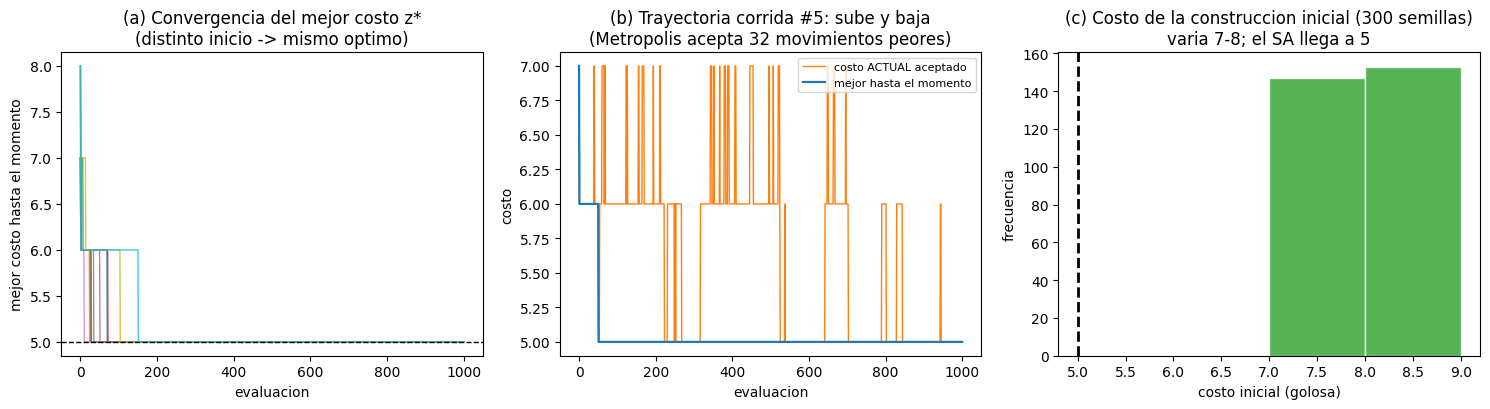


───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█

 SIMULATED ANNEALING (SA) para el SCP)
 Referencia - Jacobs & Brusco (1995), NRL 42:1129-1140
 Instancia            : /content/02_medio.txt
 Elementos (n)        : 200
 Subconjuntos (m)     : 1000
 Parametros           : rho1=0.4, rho2=2.0, T0=1.3, CF=0.9, TL=100
 Presupuesto          : 1000 evaluaciones (tope 60s)
 Corridas             : 10
 Semilla base         : 12345

 Corrida | Funcion objetivo Z(S*)
 --------+-----------------------
     1   | 433.00
     2   | 433.00
     3   | 433.00
     4   | 433.00
     5   | 433.00
     6   | 433.00
     7   | 433.00
     8   | 433.00
     9   | 433.00
    10   | 433.00
 --------+-----------------------

 Media               : 433.0000
 Desviacion estandar : 0.0000
 Minimo (mejor)      : 433.00
 Maximo (peor)       : 433.00

----------------------------------------------------------------
 MEJOR SOLUCION ENCONTRADA (sobre todas la

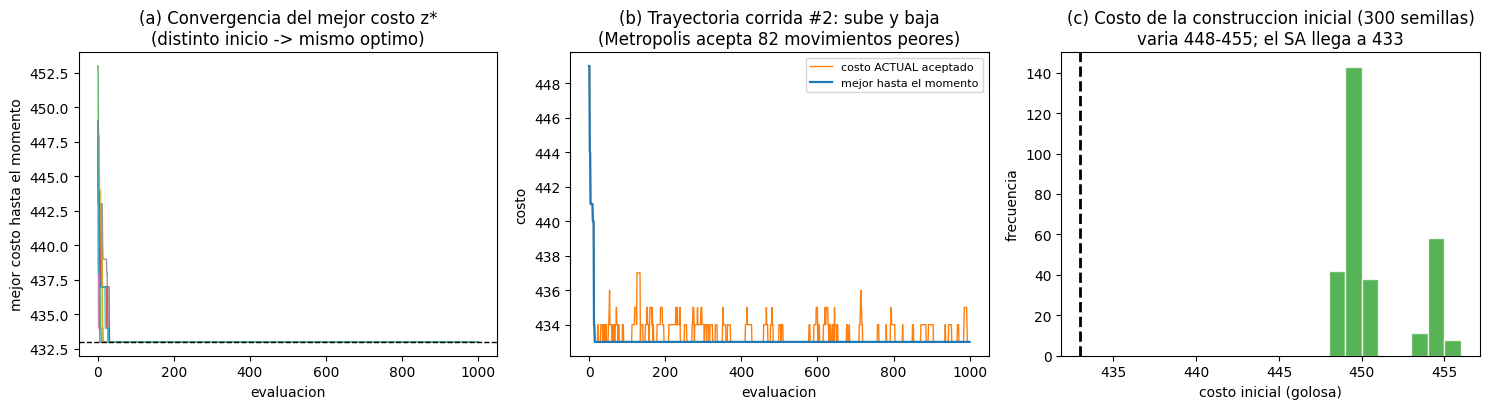


───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█

 SIMULATED ANNEALING (SA) para el SCP)
 Referencia - Jacobs & Brusco (1995), NRL 42:1129-1140
 Instancia            : /content/03_dificil.txt
 Elementos (n)        : 200
 Subconjuntos (m)     : 2000
 Parametros           : rho1=0.4, rho2=2.0, T0=1.3, CF=0.9, TL=100
 Presupuesto          : 1000 evaluaciones (tope 60s)
 Corridas             : 10
 Semilla base         : 12345

 Corrida | Funcion objetivo Z(S*)
 --------+-----------------------
     1   | 269.00
     2   | 269.00
     3   | 269.00
     4   | 269.00
     5   | 269.00
     6   | 269.00
     7   | 269.00
     8   | 269.00
     9   | 269.00
    10   | 269.00
 --------+-----------------------

 Media               : 269.0000
 Desviacion estandar : 0.0000
 Minimo (mejor)      : 269.00
 Maximo (peor)       : 269.00

----------------------------------------------------------------
 MEJOR SOLUCION ENCONTRADA (sobre todas 

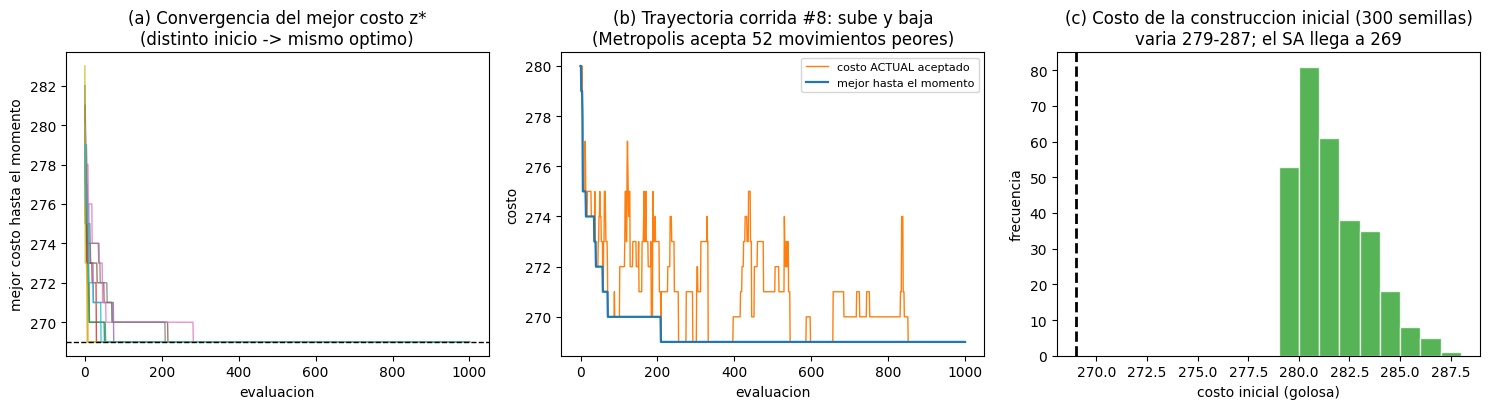


───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█



In [24]:

# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘ M A  I N ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘
# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘

en_notebook = ("ipykernel" in sys.modules) or any(
isinstance(a, str) and a.endswith(".json") and "kernel" in a
for a in sys.argv
)

main("/content/01_facil.txt")
diagnostico_metaheuristica("/content/01_facil.txt")
print("""
───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█
""")

main("/content/02_medio.txt")
diagnostico_metaheuristica("/content/02_medio.txt")
print("""
───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█
""")

main("/content/03_dificil.txt")
diagnostico_metaheuristica("/content/03_dificil.txt")
print("""
───▄▀▀▀▄▄▄▄▄▄▄▀▀▀▄───
───█▒▒░░░░░░░░░▒▒█───
────█░░█░░░░░█░░█────
─▄▄──█░░░▀█▀░░░█──▄▄─
█░░█─▀▄░░░░░░░▄▀─█░░█
""")

# ⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘⫘


# GRAFICAS

Cuando el resultado final es invariante (sigma = 0), el boxplot del resultado no aporta informacion. La senal esta en el PROCESO de busqueda, no en el resultado. Este script construye comparativas del proceso entre instancias usando la telemetria que ya recolecta el notebook (recolectar_traza=True).

**Genera DOS figuras:**
   1) comparacion_proceso.png : 3 paneles que comparan las 3 instancias en
      (A) brecha del constructor goloso que el SA cierra,
      (B) actividad de Metropolis (% de empeoramientos aceptados),
      (C) diversidad del paisaje (niveles de costo distintos visitados).
   2) convergencia.png : curvas best-so-far por evaluacion (el grafico "estandar" de una metaheuristica). Requiere las instancias .txt y las
      funciones del notebook; se omite limpiamente si no estan disponibles.


Instancia            |    z* | gap inicial | % acept.peor | niveles costo
--------------------------------------------------------------------------
I1 (n=50, m=500)     |     5 |       48.0% |        32.4% |           3.7
I2 (n=200, m=1000)   |   433 |        3.7% |        18.6% |          16.8
I3 (n=200, m=2000)   |   269 |        4.3% |         9.0% |          13.8
Figura guardada en: comparacion_proceso.png


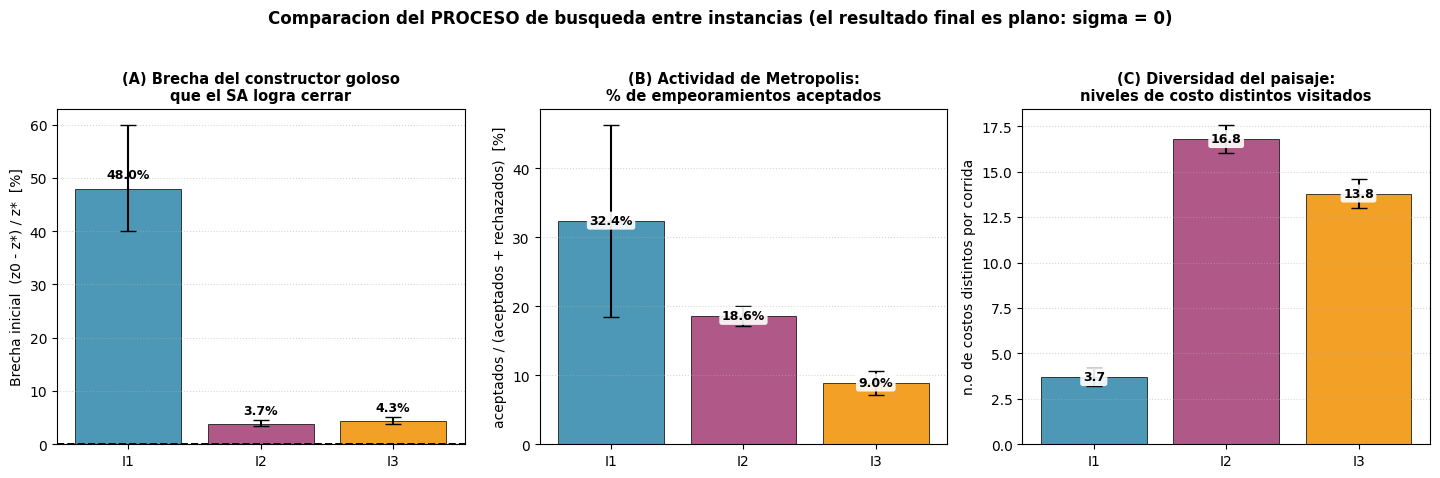

In [25]:


USAR_TELEMETRIA_EMBEBIDA = True

INSTANCIAS = {
    "I1 (n=50, m=500)":    "/content/01_facil.txt",
    "I2 (n=200, m=1000)":  "/content/02_medio.txt",
    "I3 (n=200, m=2000)":  "/content/03_dificil.txt",
}

TELEMETRIA_EMBEBIDA = {
    "I1 (n=50, m=500)": {
        "zstar": 5,
        "z0":      [7, 7, 8, 8, 7, 7, 7, 7, 8, 8],
        "acepta":  [17, 14, 30, 14, 32, 9, 0, 25, 7, 17],
        "rechaza": [32, 30, 70, 21, 82, 12, 1, 29, 23, 19],
        "ncostos": [4, 3, 4, 4, 4, 3, 3, 4, 4, 4],
    },
    "I2 (n=200, m=1000)": {
        "zstar": 433,
        "z0":      [449, 449, 453, 449, 448, 448, 449, 449, 448, 449],
        "acepta":  [80, 82, 69, 73, 60, 68, 80, 68, 73, 65],
        "rechaza": [321, 319, 323, 299, 306, 304, 335, 301, 296, 331],
        "ncostos": [18, 17, 16, 16, 17, 17, 17, 16, 18, 16],
    },
    "I3 (n=200, m=2000)": {
        "zstar": 269,
        "z0":      [281, 280, 280, 281, 281, 282, 280, 280, 283, 279],
        "acepta":  [51, 47, 28, 34, 35, 41, 43, 52, 44, 42],
        "rechaza": [387, 438, 445, 445, 428, 404, 455, 420, 409, 422],
        "ncostos": [14, 15, 14, 14, 13, 13, 14, 13, 15, 13],
    },
}

def recolectar_telemetria(semilla_base=12345, num_corridas=10):
    tele = {}
    for nombre, ruta in INSTANCIAS.items():
        inst = leer_instancia_scp(ruta)
        d = {"zstar": None, "z0": [], "acepta": [], "rechaza": [], "ncostos": []}
        for c in range(1, num_corridas + 1):
            rng = random.Random(semilla_base + c)
            sol = recocido_simulado(
                inst, rho1=0.4, rho2=2.0, T0=1.3, CF=0.9, TL=100,
                max_evaluaciones=1000, max_tiempo=60.0, rng=rng,
                recolectar_traza=True
            )
            t = sol["telemetria"]
            d["z0"].append(t["costo_inicial"])
            d["acepta"].append(t["n_acepta_peor"])
            d["rechaza"].append(t["n_rechaza"])
            d["ncostos"].append(t["costos_distintos"])
            d["zstar"] = t["costo_final"]
        tele[nombre] = d
    return tele

def figura_comparacion(tele, archivo="comparacion_proceso.png"):
    inst = list(tele.keys())
    col = ["#2E86AB", "#A23B72", "#F18F01"]
    x = list(range(len(inst)))

    gap = {k: [(z0 - v["zstar"]) / v["zstar"] * 100 for z0 in v["z0"]]
           for k, v in tele.items()}
    tasa = {k: [a / (a + r) * 100 for a, r in zip(v["acepta"], v["rechaza"])]
            for k, v in tele.items()}
    ncos = {k: v["ncostos"] for k, v in tele.items()}

    fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.6))

    gmed = [st.mean(gap[k]) for k in inst]
    ylo = [max(0.0, st.mean(gap[k]) - min(gap[k])) for k in inst]
    yhi = [max(0.0, max(gap[k]) - st.mean(gap[k])) for k in inst]
    ax[0].bar(x, gmed, yerr=[ylo, yhi], color=col, alpha=0.85, capsize=6,
              edgecolor="black", linewidth=0.6)
    ax[0].axhline(0, color="black", lw=1.4, ls="--")
    for xi, m in zip(x, gmed):
        ax[0].text(xi, m + 0.03 * max(gmed) + 0.5, f"{m:.1f}%", ha="center",
                   fontsize=9, fontweight="bold")
    ax[0].set_title("(A) Brecha del constructor goloso\nque el SA logra cerrar",
                    fontsize=10.5, fontweight="bold")
    ax[0].set_ylabel("Brecha inicial  (z0 - z*) / z*  [%]")

    tmed = [st.mean(tasa[k]) for k in inst]
    tsd = [st.stdev(tasa[k]) for k in inst]
    ax[1].bar(x, tmed, yerr=tsd, color=col, alpha=0.85, capsize=6,
              edgecolor="black", linewidth=0.6)
    for xi, m in zip(x, tmed):
        ax[1].text(xi, m, f"{m:.1f}%", ha="center", va="center", fontsize=9,
                   fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))
    ax[1].set_title("(B) Actividad de Metropolis:\n% de empeoramientos aceptados",
                    fontsize=10.5, fontweight="bold")
    ax[1].set_ylabel("aceptados / (aceptados + rechazados)  [%]")

    # (C) diversidad del paisaje
    cmed = [st.mean(ncos[k]) for k in inst]
    csd = [st.stdev(ncos[k]) for k in inst]
    ax[2].bar(x, cmed, yerr=csd, color=col, alpha=0.85, capsize=6,
              edgecolor="black", linewidth=0.6)
    for xi, m in zip(x, cmed):
        ax[2].text(xi, m, f"{m:.1f}", ha="center", va="center", fontsize=9,
                   fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))
    ax[2].set_title("(C) Diversidad del paisaje:\nniveles de costo distintos visitados",
                    fontsize=10.5, fontweight="bold")
    ax[2].set_ylabel("n.o de costos distintos por corrida")

    etiquetas = [k.split(" ")[0] for k in inst]
    for a in ax:
        a.set_xticks(x)
        a.set_xticklabels(etiquetas)
        a.grid(axis="y", ls=":", alpha=0.5)

    fig.suptitle("Comparacion del PROCESO de busqueda entre instancias "
                 "(el resultado final es plano: sigma = 0)",
                 fontsize=12, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.savefig(archivo, dpi=150, bbox_inches="tight")
    print(f"Figura guardada en: {archivo}")
    plt.show()

def figura_convergencia(semilla_base=12345, num_corridas=10,
                        archivo="convergencia.png"):
    """Grafico estandar de metaheuristica: mejor costo hasta el momento vs.
    evaluacion. Una linea por corrida, un panel por instancia. Requiere las
    instancias .txt y las funciones del notebook."""
    fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
    for j, (nombre, ruta) in enumerate(INSTANCIAS.items()):
        inst = leer_instancia_scp(ruta)                       # noqa: F821
        zstar = None
        for c in range(1, num_corridas + 1):
            rng = random.Random(semilla_base + c)
            sol = recocido_simulado(                          # noqa: F821
                inst, rho1=0.4, rho2=2.0, T0=1.3, CF=0.9, TL=100,
                max_evaluaciones=1000, max_tiempo=60.0, rng=rng,
                recolectar_traza=True
            )
            traza = sol["telemetria"]["traza_mejor"]
            zstar = sol["telemetria"]["costo_final"]
            ax[j].plot(traza, lw=1, alpha=0.8)
        ax[j].axhline(zstar, ls="--", lw=1, color="black")
        ax[j].set_title(nombre, fontsize=10.5, fontweight="bold")
        ax[j].set_xlabel("evaluacion")
        ax[j].set_ylabel("mejor costo hasta el momento")
        ax[j].grid(ls=":", alpha=0.5)
    fig.suptitle("Convergencia del mejor costo: 10 inicios distintos -> mismo optimo",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(archivo, dpi=150, bbox_inches="tight")
    print(f"Figura guardada en: {archivo}")
    plt.show()


def resumen(tele):
    print(f"{'Instancia':<20} | {'z*':>5} | {'gap inicial':>11} | "
          f"{'% acept.peor':>12} | {'niveles costo':>13}")
    print("-" * 74)
    for k, v in tele.items():
        gap = st.mean([(z0 - v["zstar"]) / v["zstar"] * 100 for z0 in v["z0"]])
        tasa = st.mean([a / (a + r) * 100 for a, r in zip(v["acepta"], v["rechaza"])])
        nc = st.mean(v["ncostos"])
        print(f"{k:<20} | {v['zstar']:>5} | {gap:>10.1f}% | "
              f"{tasa:>11.1f}% | {nc:>13.1f}")



if USAR_TELEMETRIA_EMBEBIDA:
      tele = TELEMETRIA_EMBEBIDA
else:
      tele = recolectar_telemetria()
resumen(tele)
figura_comparacion(tele)
if not USAR_TELEMETRIA_EMBEBIDA:
      figura_convergencia()